In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')

In [15]:
data = tf.keras.utils.image_dataset_from_directory(directory = '/Users/prana/OneDrive/Desktop/6TH Sem Cources/Minor Project 2/NEW DATA/dataset',
                                                   color_mode = 'rgb',
                                                   batch_size = 64,
                                                   image_size = (224,224),
                                                   shuffle=True,
                                                   seed = 2022)

Found 4217 files belonging to 4 classes.


In [16]:
labels = np.concatenate([y for x,y in data], axis=0)
values = pd.value_counts(labels)
values = values.sort_index()
values

0    1038
1    1098
2    1007
3    1074
dtype: int64

In [17]:
class_names = data.class_names
for idx, name in enumerate(class_names):
  print(f"{idx} = {name}", end=", ")

0 = cataract, 1 = diabetic_retinopathy, 2 = glaucoma, 3 = normal, 

In [18]:
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()
batch[0].shape

(64, 224, 224, 3)

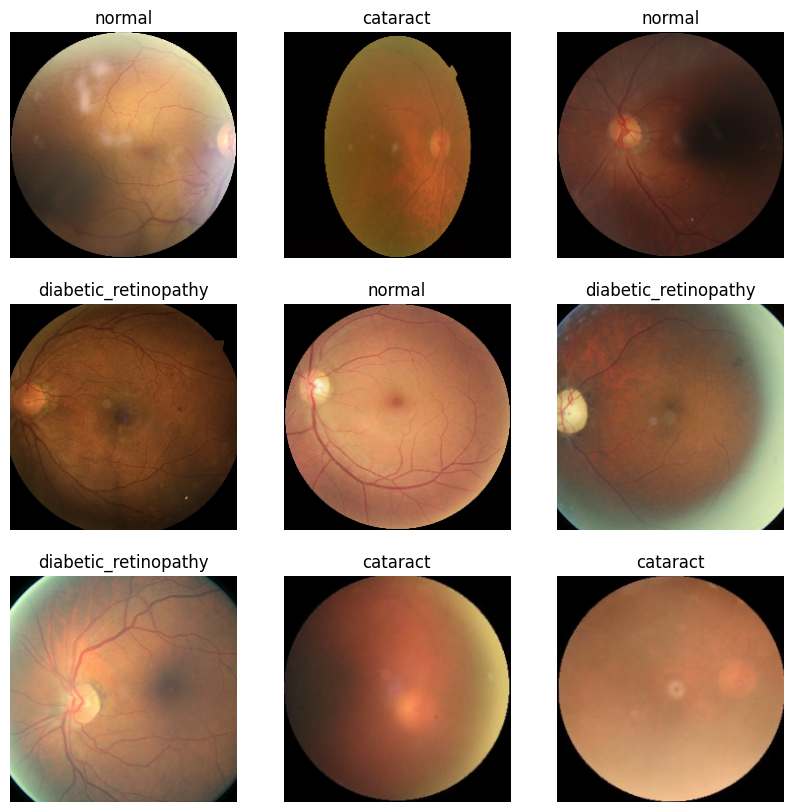

In [19]:
plt.figure(figsize=(10, 10))
for images, labels in data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [20]:
data = data.map(lambda x, y: (x/255, y))

In [21]:
sample = data.as_numpy_iterator().next()

In [22]:
print(sample[0].min())
print(sample[0].max())

0.0
1.0


In [23]:
print("Total number of batchs = ",len(data))

Total number of batchs =  66


In [24]:
train_size = int(0.7 * len(data)) +1
val_size = int(0.2 * len(data))
test_size = int(0.1 * len(data))

In [25]:
train = data.take(train_size)
remaining = data.skip(train_size)
val = remaining.take(val_size)
test = remaining.skip(val_size)

In [26]:
print(f"# train batchs = {len(train)}, # validate batchs = {len(val)}, # test batch = {len(test)}")
len(train) + len(val) + len(test)

# train batchs = 47, # validate batchs = 13, # test batch = 6


66

In [27]:
test_iter = test.as_numpy_iterator()

In [28]:
test_set = {"images":np.empty((0,224,224,3)), "labels":np.empty(0)}
while True:
  try:
    batch = test_iter.next()
    test_set['images'] = np.concatenate((test_set['images'], batch[0]))
    test_set['labels'] = np.concatenate((test_set['labels'], batch[1]))
  except:
    break

In [29]:
y_true = test_set['labels']


In [30]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Dropout, Flatten, BatchNormalization
from keras.applications.efficientnet import EfficientNetB3
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, Adamax

In [31]:
# Displaying history loss/accuracy
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_his(history):
    plt.figure(figsize=(15,12))
    metrics = ['accuracy', 'loss']
    for i, metric in enumerate(metrics):
        plt.subplot(220+1+i)
        plt.plot(history.epoch, history.history[metric], color=colors[0], label='Train')
        plt.plot(history.epoch, history.history['val_'+metric],
                 color=colors[1], linestyle="--", label='Val')
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.legend()
    plt.show()

In [32]:
def create_baselineCNN():
    model = Sequential([
        Conv2D(filters = 64, kernel_size=3, activation = 'relu',padding='same', input_shape=(224,224,3)),
        Conv2D(filters = 64, kernel_size=3, activation = 'relu',padding='same'),
        BatchNormalization(),
        MaxPool2D(2),
        Dropout(0.3),

        Conv2D(filters = 128, kernel_size=3,padding='same', activation = 'relu',),
        Conv2D(filters = 128, kernel_size=3,padding='same', activation = 'relu',),
        BatchNormalization(),
        MaxPool2D(2),
        Dropout(0.3),
        
         
        Conv2D(filters = 128, kernel_size=3,padding='same', activation = 'relu',),
        Conv2D(filters = 128, kernel_size=3,padding='same', activation = 'relu',),
        BatchNormalization(),
        Conv2D(filters = 128, kernel_size=3,padding='same', activation = 'relu',),
        BatchNormalization(),
        MaxPool2D(2),
        Dropout(0.3),
        
        Flatten(),
        Dense(64, activation = 'relu'),
        Dropout(0.3),
        BatchNormalization(),
        Dense(128, activation = 'relu'),
        Dropout(0.3),
        BatchNormalization(),
        Dense(4, activation='softmax')
    ])
    model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer='adam', metrics=['accuracy'])
    return model


In [33]:
model = create_baselineCNN()


In [34]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 224, 224, 64)      1792      
                                                                 
 conv2d_8 (Conv2D)           (None, 224, 224, 64)      36928     
                                                                 
 batch_normalization_6 (Batc  (None, 224, 224, 64)     256       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 112, 112, 64)     0         
 2D)                                                             
                                                                 
 dropout_5 (Dropout)         (None, 112, 112, 64)      0         
                                                                 
 conv2d_9 (Conv2D)           (None, 112, 112, 128)    

In [35]:
from keras import callbacks 
early_stop = callbacks.EarlyStopping(
        monitor="val_accuracy", 
        patience=20,
        verbose=1,
        mode="max",
        restore_best_weights=True, 
     )

history = model.fit(
    train,
    validation_data=val,
    epochs = 60,
    callbacks=[early_stop],
)

Epoch 1/60


2023-05-03 13:09:01.996998: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/dropout_5/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


47/47 [==============================] - 60s 902ms/step - loss: 1.3688 - accuracy: 0.4269 - val_loss: 2.0952 - val_accuracy: 0.2524
Epoch 2/60
47/47 [==============================] - 46s 928ms/step - loss: 0.9916 - accuracy: 0.5701 - val_loss: 3.3005 - val_accuracy: 0.2740
Epoch 3/60
47/47 [==============================] - 45s 905ms/step - loss: 0.8703 - accuracy: 0.6074 - val_loss: 4.7682 - val_accuracy: 0.2392
Epoch 4/60
47/47 [==============================] - 45s 904ms/step - loss: 0.7188 - accuracy: 0.6978 - val_loss: 4.1274 - val_accuracy: 0.2440
Epoch 5/60
47/47 [==============================] - 45s 914ms/step - loss: 0.7063 - accuracy: 0.6918 - val_loss: 0.8338 - val_accuracy: 0.6022
Epoch 6/60
47/47 [==============================] - 45s 904ms/step - loss: 0.7146 - accuracy: 0.6779 - val_loss: 1.9746 - val_accuracy: 0.2596
Epoch 7/60
47/47 [==============================] - 46s 937ms/step - loss: 0.6323 - accuracy: 0.7337 - val_loss: 6.7754 - val_accuracy: 0.2476
Epoch 8/60

In [37]:
y_pred = np.argmax(model.predict(test_set['images']), 1)

12/12 [==============================] - 3s 151ms/step


In [38]:
print(classification_report(y_true, y_pred, target_names = class_names))


                      precision    recall  f1-score   support

            cataract       0.89      0.96      0.92        92
diabetic_retinopathy       0.99      1.00      0.99        96
            glaucoma       0.89      0.73      0.80        92
              normal       0.82      0.90      0.86        97

            accuracy                           0.90       377
           macro avg       0.90      0.90      0.89       377
        weighted avg       0.90      0.90      0.89       377



Text(0.5, 1.0, 'Confusion Matrix')

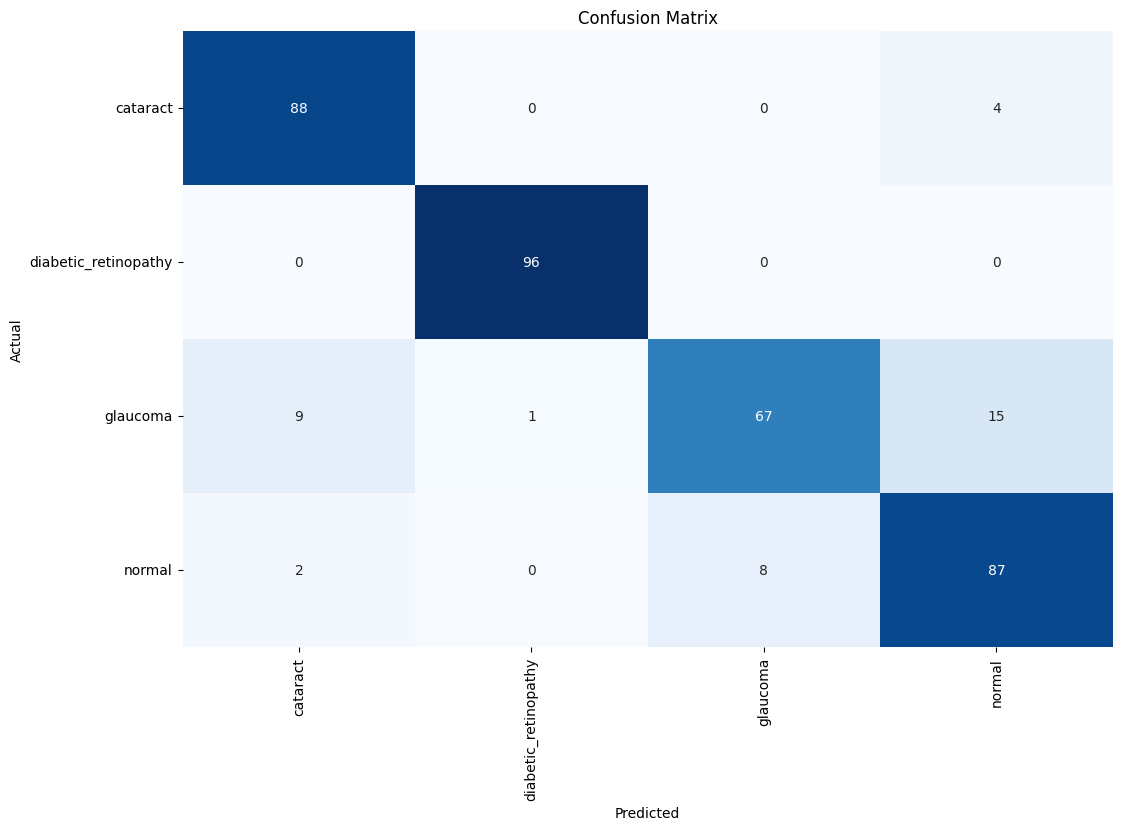

In [39]:
confusion_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
plt.xticks(np.arange(4)+.5, class_names, rotation=90)
plt.yticks(np.arange(4)+.5, class_names, rotation=0)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")